# Test Algorithm Performance

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor

from hirank import RankOD

In [2]:
def ood_train_test_split(X, y, hold_out_label, rng=np.random.default_rng()):
    # Split into normal and ood sets
    ood_mask = y == hold_out_label

    X_inlier = X[~ood_mask]
    y_inlier = y[~ood_mask]
    X_outlier = X[ood_mask]
    y_outlier = y[ood_mask]

    inlier_test_mask = np.zeros(X_inlier.shape[0], dtype="bool")
    inlier_test_mask[rng.choice(np.arange(len(inlier_test_mask)), size=np.sum(ood_mask), replace=False)] = True

    X_train = X_inlier[~inlier_test_mask]
    y_train = y_inlier[~inlier_test_mask]
    X_test = np.vstack([X_outlier, X_inlier[inlier_test_mask]])
    y_test = np.concatenate([y_outlier, y_inlier[inlier_test_mask]])
    y_ood = y_test == hold_out_label

    split = {"x_train":X_train, "x_test":X_test, "y_test":y_test, "y_ood":y_ood, "hold_out_label":hold_out_label}
    return split

## Global Parameters

In [3]:
n_samples = 10000

## Load Data

### MNIST

In [4]:
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# Take a subset for faster computation
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

Loading MNIST dataset...
✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(990), 1: np.int64(1074), 2: np.int64(1051), 3: np.int64(1021), 4: np.int64(929), 5: np.int64(913), 6: np.int64(969), 7: np.int64(1060), 8: np.int64(974), 9: np.int64(1019)}


In [5]:
mnist_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in mnist_splits:
    split["dataset"] = "mnist"
len(mnist_splits)

10

### Fashion MNSIT

In [6]:
fashion = fetch_openml('Fashion-MNIST', version=1, parser='auto')
X = fashion.data.to_numpy()
y = fashion.target.astype(int).to_numpy()

# Take a subset for faster computation
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(937), 1: np.int64(1052), 2: np.int64(1063), 3: np.int64(969), 4: np.int64(981), 5: np.int64(989), 6: np.int64(971), 7: np.int64(1056), 8: np.int64(1024), 9: np.int64(958)}


In [7]:
fashion_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in fashion_splits:
    split["dataset"] = "fashion"
len(fashion_splits)

10

### Aggregate all splits

In [8]:
splits = mnist_splits + fashion_splits
len(splits)

20

## Define Methods

In [9]:
rank_l2_invsqrt_local = RankOD(
    mode = "rank",
    calibration = "local",
    max_rank = 50,
    random_state = 42,
)

rank_l2_invsqrt_global = RankOD(
    mode = "rank",
    calibration = "global",
    max_rank = 50,
    random_state = 42,
)

rank_l2_linear_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "linear",
    max_rank = 50,
    random_state = 42,
)

rank_l2_linear_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "linear",
    max_rank = 50,
    random_state = 42,
)

rank_l2_inverselog_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "inverse_log",
    max_rank = 50,
    random_state = 42,
)

rank_l2_inverselog_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "inverse_log",
    max_rank = 50,
    random_state = 42,
)

rank_l2_invsqrt_local = RankOD(
    mode = "rank",
    calibration = "local",
    max_rank = 50,
    random_state = 42,
)

rank_cos_invsqrt_global = RankOD(
    mode = "rank",
    calibration = "global",
    max_rank = 50,
    random_state = 42,
)

rank_cos_linear_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "linear",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

rank_cos_linear_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "linear",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

rank_cos_inverselog_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "inverse_log",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

rank_cos_inverselog_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "inverse_log",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

sun_global = RankOD(
    mode = "sun",
    calibration = "raw",
    random_state = 42,
)

sun_local = RankOD(
    mode = "rank",
    calibration = "global",
    random_state = 42,
)

lof = LocalOutlierFactor(
    novelty=True,
)

iso = IsolationForest(
    random_state = 42,
)

methods = [
    rank_l2_invsqrt_local,
    rank_l2_invsqrt_global,
    rank_l2_linear_local,
    rank_l2_linear_global,
    rank_l2_invsqrt_local,
    rank_cos_invsqrt_global,
    rank_cos_linear_local,
    rank_cos_linear_global,
    sun_global,
    sun_local,
    lof,
    iso,
]

method_names = [
    'rank_l2_invsqrt_local',
    'rank_l2_invsqrt_global',
    'rank_l2_linear_local',
    'rank_l2_linear_global',
    'rank_l2_invsqrt_local',
    'rank_cos_invsqrt_global',
    'rank_cos_linear_local',
    'rank_cos_linear_global',
    'sun_global',
    'sun_local',
    'lof',
    'iso',
]

## Run Tests

In [10]:
print(f"Testing {len(methods)} methods on {len(splits)} train/test splits.")
results = []
for split in splits:
    print(f"Testing dataset {split["dataset"]} with ood class {split["hold_out_label"]}")
    for method, method_name in zip(methods, method_names):
        result = {"dataset":split["dataset"], "method":method_name, "ood class":str(split["hold_out_label"])}
        # Warmup cache
        X = np.random.random((100, 30))
        X_test = np.random.random((100, 30))
        with warnings.catch_warnings() as caught:
            warnings.simplefilter("ignore", category=UserWarning)
            method.fit(X)
            method.score_samples(X_test)

        # Fit
        method.fit(split["x_train"])
        # Predict
        scores = method.score_samples(split["x_test"])
        # Evaluate
        result["auroc"] = roc_auc_score(~split["y_ood"], scores)
        results.append(result)

Testing 12 methods on 20 train/test splits.
Testing dataset mnist with ood class 0
Testing dataset mnist with ood class 1
Testing dataset mnist with ood class 2
Testing dataset mnist with ood class 3
Testing dataset mnist with ood class 4
Testing dataset mnist with ood class 5
Testing dataset mnist with ood class 6
Testing dataset mnist with ood class 7
Testing dataset mnist with ood class 8
Testing dataset mnist with ood class 9
Testing dataset fashion with ood class 0
Testing dataset fashion with ood class 1
Testing dataset fashion with ood class 2
Testing dataset fashion with ood class 3
Testing dataset fashion with ood class 4
Testing dataset fashion with ood class 5
Testing dataset fashion with ood class 6
Testing dataset fashion with ood class 7
Testing dataset fashion with ood class 8
Testing dataset fashion with ood class 9


In [11]:
df = pd.DataFrame(results)
df

,dataset,method,ood class,auroc
0,mnist,rank_l2_invsqrt_local,0,0.764636
1,mnist,rank_l2_invsqrt_global,0,0.921403
2,mnist,rank_l2_linear_local,0,0.786987
3,mnist,rank_l2_linear_global,0,0.928598
4,mnist,rank_l2_invsqrt_local,0,0.764636
...,...,...,...,...
235,fashion,rank_cos_linear_global,9,0.436745
236,fashion,sun_global,9,0.775398
237,fashion,sun_local,9,0.675719
238,fashion,lof,9,0.744153


In [12]:
dataset_means = df.groupby(["dataset", "method"])[["auroc"]].mean().reset_index()
dataset_means["ood class"] = "Average"
df = pd.concat([df, dataset_means])
df

,dataset,method,ood class,auroc
0,mnist,rank_l2_invsqrt_local,0,0.764636
1,mnist,rank_l2_invsqrt_global,0,0.921403
2,mnist,rank_l2_linear_local,0,0.786987
3,mnist,rank_l2_linear_global,0,0.928598
4,mnist,rank_l2_invsqrt_local,0,0.764636
...,...,...,...,...
17,mnist,rank_l2_invsqrt_local,Average,0.798817
18,mnist,rank_l2_linear_global,Average,0.888599
19,mnist,rank_l2_linear_local,Average,0.804367
20,mnist,sun_global,Average,0.865646


In [13]:
df.to_feather("comparing_modes_results.feather")

In [14]:
# Fix so all plots share hues
hue_order = df["method"].unique().tolist()
hue_order

['rank_l2_invsqrt_local',
 'rank_l2_invsqrt_global',
 'rank_l2_linear_local',
 'rank_l2_linear_global',
 'rank_cos_invsqrt_global',
 'rank_cos_linear_local',
 'rank_cos_linear_global',
 'sun_global',
 'sun_local',
 'lof',
 'iso']

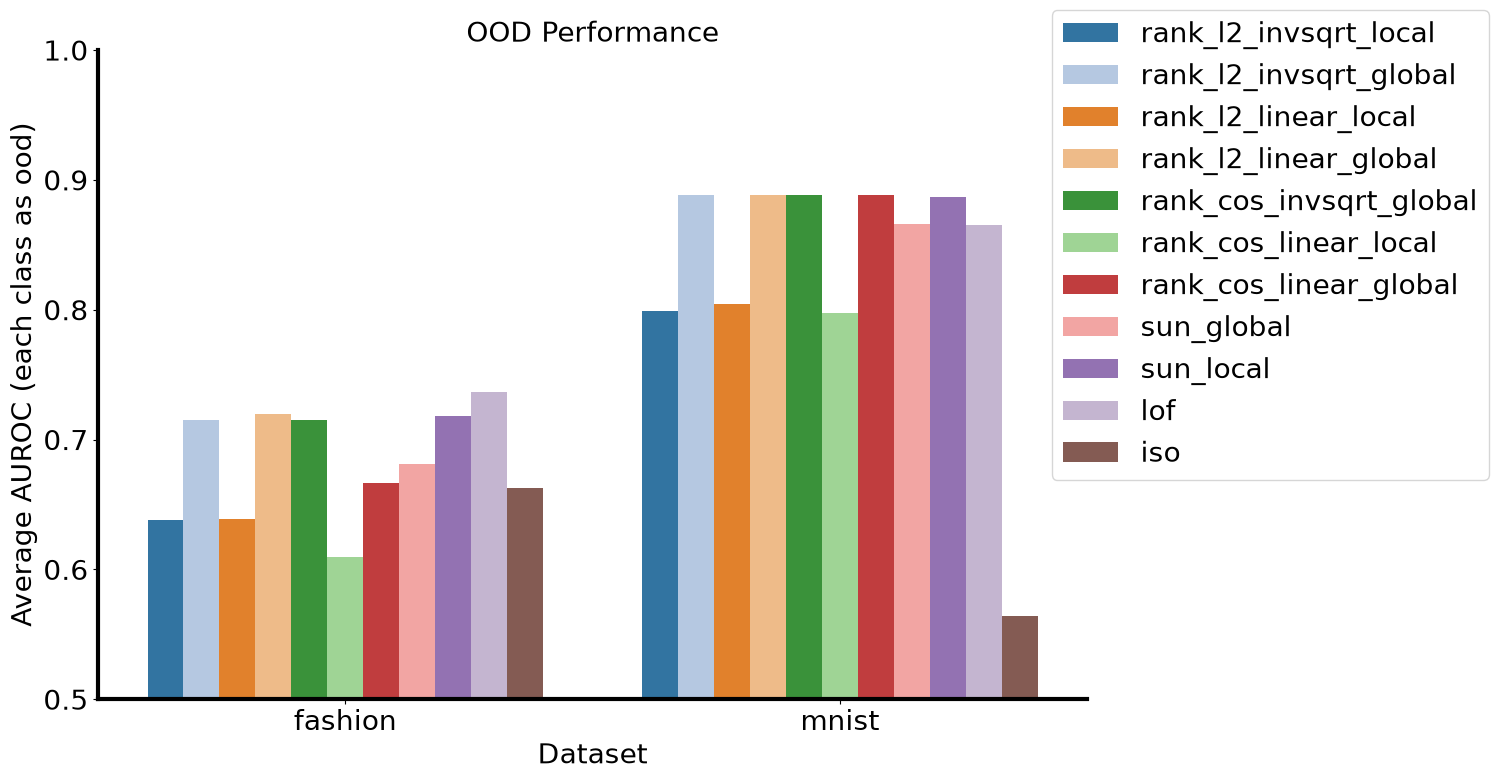

In [15]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.barplot(df[df["ood class"] == "Average"], x="dataset", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance", fontsize=20)
ax.set_xlabel("Dataset", fontsize=20)
ax.set_ylabel("Average AUROC (each class as ood)", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.95, 0.7), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

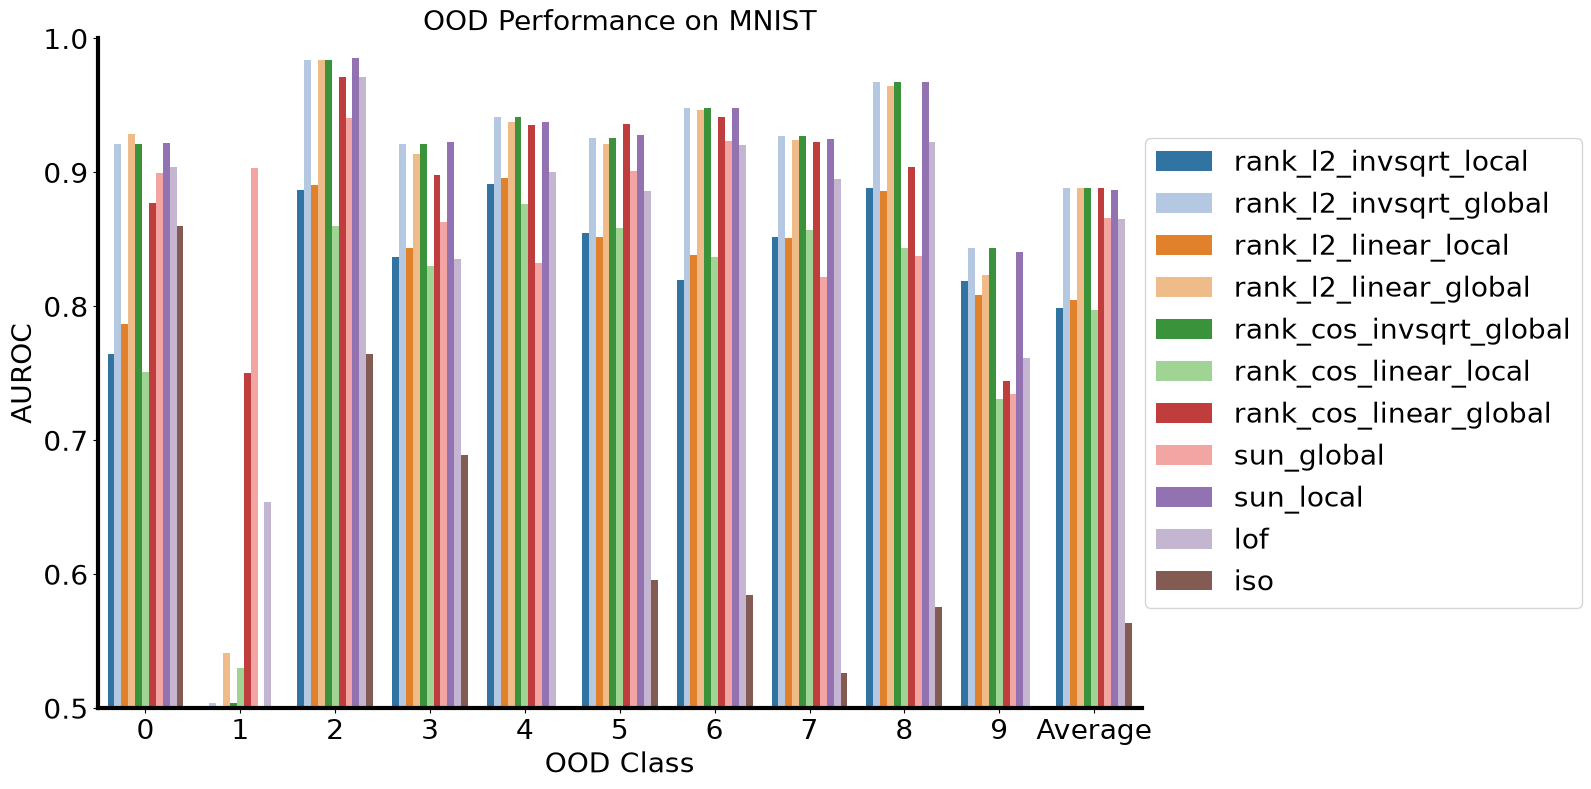

In [16]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "mnist"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.99, 0.5), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

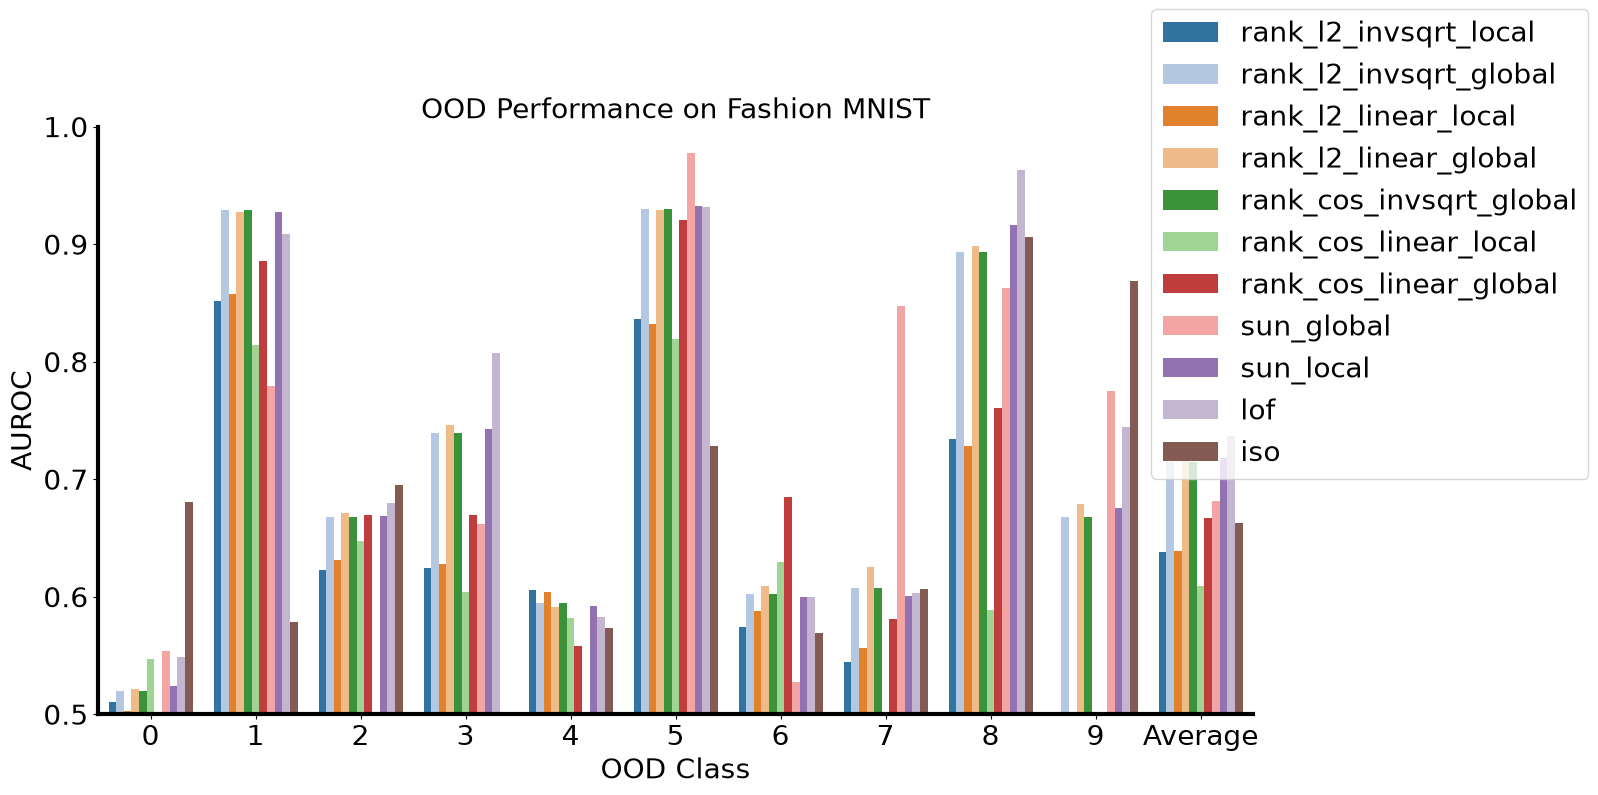

In [17]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "fashion"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on Fashion MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.9, 0.8), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()